# Force Validation — Commanded vs Measured

## Cell 1 — Load Data

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SESSION_DIR = "/home/sujith/Documents/NOARK_backbone/csv_data/june_19_t2"

lc  = pd.read_csv(os.path.join(SESSION_DIR, "loadcell.csv"), parse_dates=["timestamp"])
gui = pd.read_csv(os.path.join(SESSION_DIR, "gui.csv"),      parse_dates=["timestamp"])

lc  = lc.sort_values("timestamp").reset_index(drop=True)
gui = gui.sort_values("timestamp").reset_index(drop=True)

print("lc  rows:", len(lc))
print("gui rows:", len(gui))

if len(lc) < 2 or len(gui) < 2:
    raise ValueError("One or both CSV files are empty — check SESSION_DIR: " + SESSION_DIR)

lc_hz  = len(lc)  / (lc["timestamp"].iloc[-1]  - lc["timestamp"].iloc[0]).total_seconds()
gui_hz = len(gui) / (gui["timestamp"].iloc[-1] - gui["timestamp"].iloc[0]).total_seconds()
print("loadcell : {:.1f} Hz  ({} rows)".format(lc_hz,  len(lc)))
print("gui      : {:.1f} Hz  ({} rows)".format(gui_hz, len(gui)))


lc  rows: 20793
gui rows: 10894
loadcell : 349.5 Hz  (20793 rows)
gui      : 183.1 Hz  (10894 rows)


## Cell 3 — Resample Both Streams to 100 Hz

In [2]:
from scipy.interpolate import interp1d

RESAMPLE_HZ = 100

# common reference point — relative seconds avoids float precision loss at Unix scale
t0    = min(lc["timestamp"].iloc[0], gui["timestamp"].iloc[0])
lc_t  = (lc["timestamp"]  - t0).dt.total_seconds().values
gui_t = (gui["timestamp"] - t0).dt.total_seconds().values

t_start = max(lc_t[0],  gui_t[0])
t_end   = min(lc_t[-1], gui_t[-1])
# subtract half a sample to guarantee t_grid never reaches t_end (avoids float overshoot)
t_grid     = np.arange(t_start, t_end - 0.5 / RESAMPLE_HZ, 1.0 / RESAMPLE_HZ)
timestamps = t0 + pd.to_timedelta(t_grid, unit="s")

# loadcell — linear (continuous sensor signal)
lc_new = {"timestamp": timestamps}
for col in ["Fx", "Fy"]:
    lc_new[col] = interp1d(lc_t, lc[col].values, kind="linear",
                           bounds_error=True)(t_grid)
lc = pd.DataFrame(lc_new)

# gui — previous-value hold (step-wise commanded values)
gui_new = {"timestamp": timestamps}
for col in ["magnitude", "direction", "Fx", "Fz"]:
    gui_new[col] = interp1d(gui_t, gui[col].values, kind="previous",
                            bounds_error=True)(t_grid)
gui = pd.DataFrame(gui_new)

print("loadcell : {} rows @ {} Hz".format(len(lc),  RESAMPLE_HZ))
print("gui      : {} rows @ {} Hz".format(len(gui), RESAMPLE_HZ))


loadcell : 5949 rows @ 100 Hz
gui      : 5949 rows @ 100 Hz


## Cell 4 — Merge and Compute Measured Magnitude & Direction

In [3]:
HOLD_TIME  = 2.0
STABLE_WIN = 1.0   # last 1 s of each step
NUM_MAGS   = 4     # number of magnitude levels per angle (5, 10, 15, 24)
ANGLE_STEPS = 7
NUM_STEPS  = ANGLE_STEPS * NUM_MAGS   # 28 total steps expected

lc_merge = lc[["timestamp", "Fx", "Fy"]].rename(
    columns={"Fx": "measured_Fx", "Fy": "measured_Fy"})

df = pd.merge_asof(gui[["timestamp", "magnitude", "direction", "Fx", "Fz"]],
                   lc_merge,
                   on="timestamp", direction="nearest")

df = df.rename(columns={"Fx": "given_Fx", "Fz": "given_Fz"})

df["measured_magnitude"] = np.sqrt(df["measured_Fx"]**2 + df["measured_Fy"]**2)
df["measured_direction"] = np.degrees(np.arctan2(df["measured_Fy"], df["measured_Fx"]))
df["t_sec"] = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds()

# detect actual command changes from the GUI data (zero-order hold → clean staircase)
cmd_change = (df["magnitude"].diff().abs() > 0.1) | (df["direction"].diff().abs() > 0.5)
cmd_change.iloc[0] = True  # first row starts step 0
df["step"] = (cmd_change.cumsum() - 1).astype(int)

# drop ghost steps logged after sweep ended
df = df[df["step"] < NUM_STEPS].reset_index(drop=True)

# true time elapsed since the actual command fired
step_start_t = df.groupby("step")["t_sec"].transform("min")
df["t_in_step"] = df["t_sec"] - step_start_t

# truncate each step at HOLD_TIME (last step otherwise runs until end of log)
df = df[df["t_in_step"] <= HOLD_TIME].reset_index(drop=True)

# angle changes at step boundaries where angle group increments
step_starts = df.groupby("step")["t_sec"].min()
angle_changes = step_starts[step_starts.index % NUM_MAGS == 0].values[1:]  # skip step 0
print(f"Angle transitions: {len(angle_changes)}  at t = {np.round(angle_changes, 2)} s")

out_path = os.path.join(SESSION_DIR, "force_comparison.csv")
df.to_csv(out_path, index=False)
print("Saved {} rows -> {}".format(len(df), out_path))
df.head()

Angle transitions: 6  at t = [ 7.82 15.82 23.82 31.82 39.82 47.81] s
Saved 5583 rows -> /home/sujith/Documents/NOARK_backbone/csv_data/june_19_t2/force_comparison.csv


,timestamp,magnitude,direction,given_Fx,given_Fz,measured_Fx,measured_Fy,measured_magnitude,measured_direction,t_sec,step,t_in_step
0,2026-06-19 11:35:32.276861,5.0,-129.146721,-3.156542,-3.877659,-0.260000,-0.063000,0.267524,-166.379312,0.00,0,0.00
1,2026-06-19 11:35:32.286861,5.0,-129.146721,-3.156542,-3.877659,-0.121304,0.031167,0.125244,165.590615,0.01,0,0.01
2,2026-06-19 11:35:32.296861,5.0,-129.146721,-3.156542,-3.877659,0.173375,0.122131,0.212073,35.161994,0.02,0,0.02
3,2026-06-19 11:35:32.306861,5.0,-129.146721,-3.156542,-3.877659,0.137587,0.070675,0.154678,27.188437,0.03,0,0.03
4,2026-06-19 11:35:32.316861,5.0,-129.146721,-3.156542,-3.877659,0.003811,-0.055688,0.055818,-86.085433,0.04,0,0.04


## Cell 5 — Plot Given vs Measured Fx and Fy

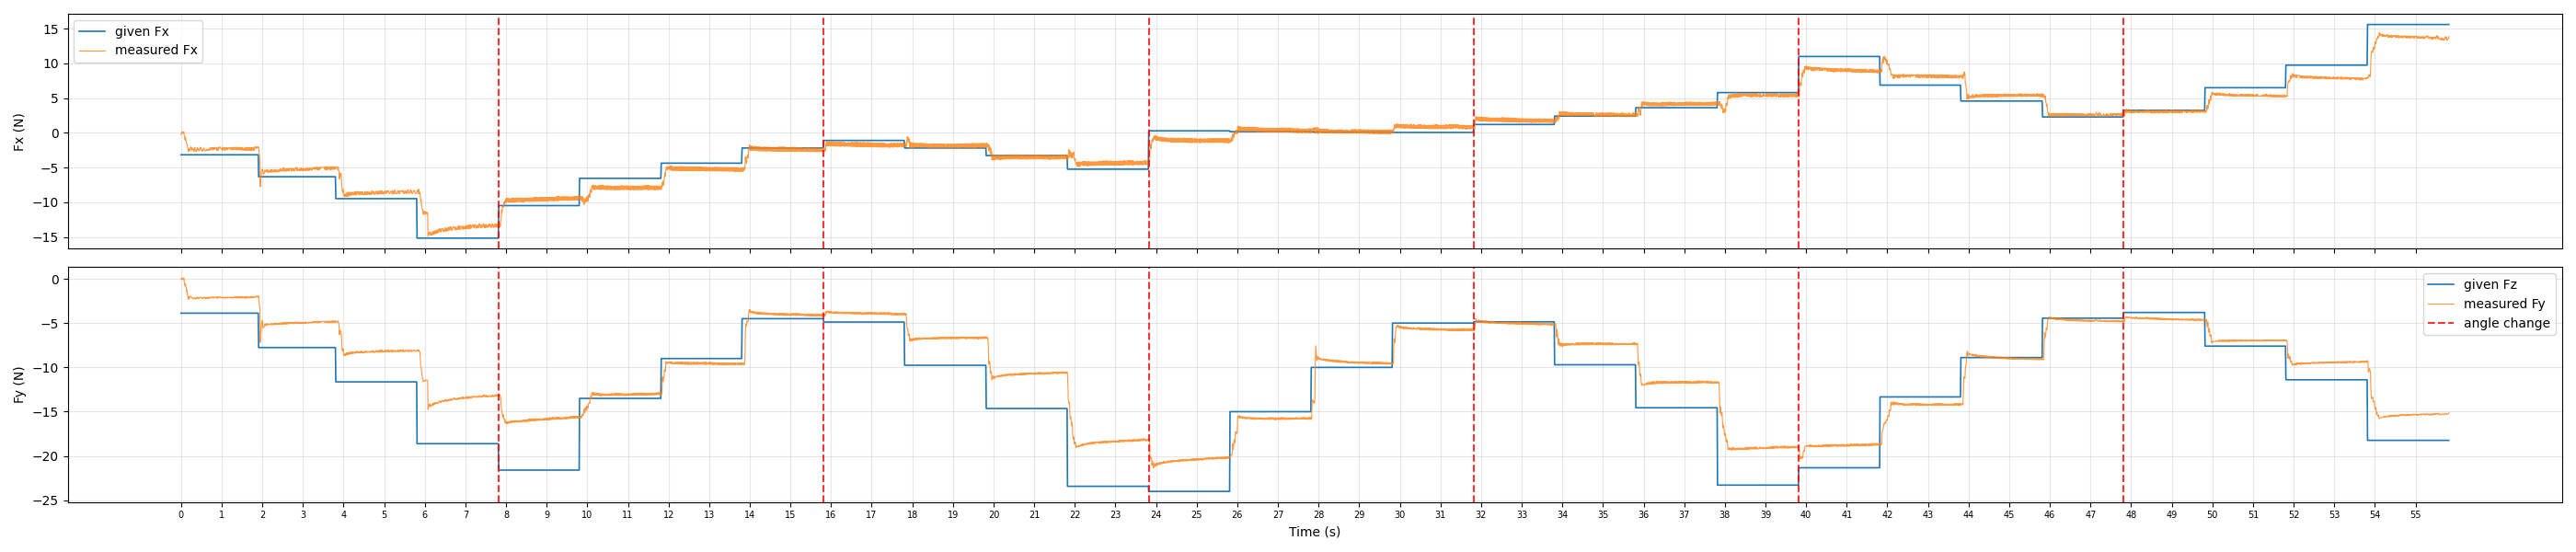

In [4]:
%matplotlib widget

fig, axes = plt.subplots(2, 1, figsize=(28, 6), sharex=True)

axes[0].plot(df["t_sec"], df["given_Fx"],    label="given Fx",    lw=1.2)
axes[0].plot(df["t_sec"], df["measured_Fx"], label="measured Fx", lw=0.8, alpha=0.8)
for t in angle_changes:
    axes[0].axvline(t, color="red", lw=1.5, ls="--", alpha=0.8)
axes[0].set_ylabel("Fx (N)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["t_sec"], df["given_Fz"],    label="given Fz",    lw=1.2)
axes[1].plot(df["t_sec"], df["measured_Fy"], label="measured Fy", lw=0.8, alpha=0.8)
for i, t in enumerate(angle_changes):
    axes[1].axvline(t, color="red", lw=1.5, ls="--", alpha=0.8,
                   label="angle change" if i == 0 else "")
axes[1].set_ylabel("Fy (N)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

t_max = int(df["t_sec"].max()) + 1
axes[1].set_xticks(range(0, t_max, 1))
axes[1].set_xticklabels(range(0, t_max, 1), fontsize=7)
axes[1].set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig(os.path.join(SESSION_DIR, "fx_fz_timeseries.png"), dpi=150)
plt.show()

## Cell 6 — Plot Given vs Measured Magnitude and Direction

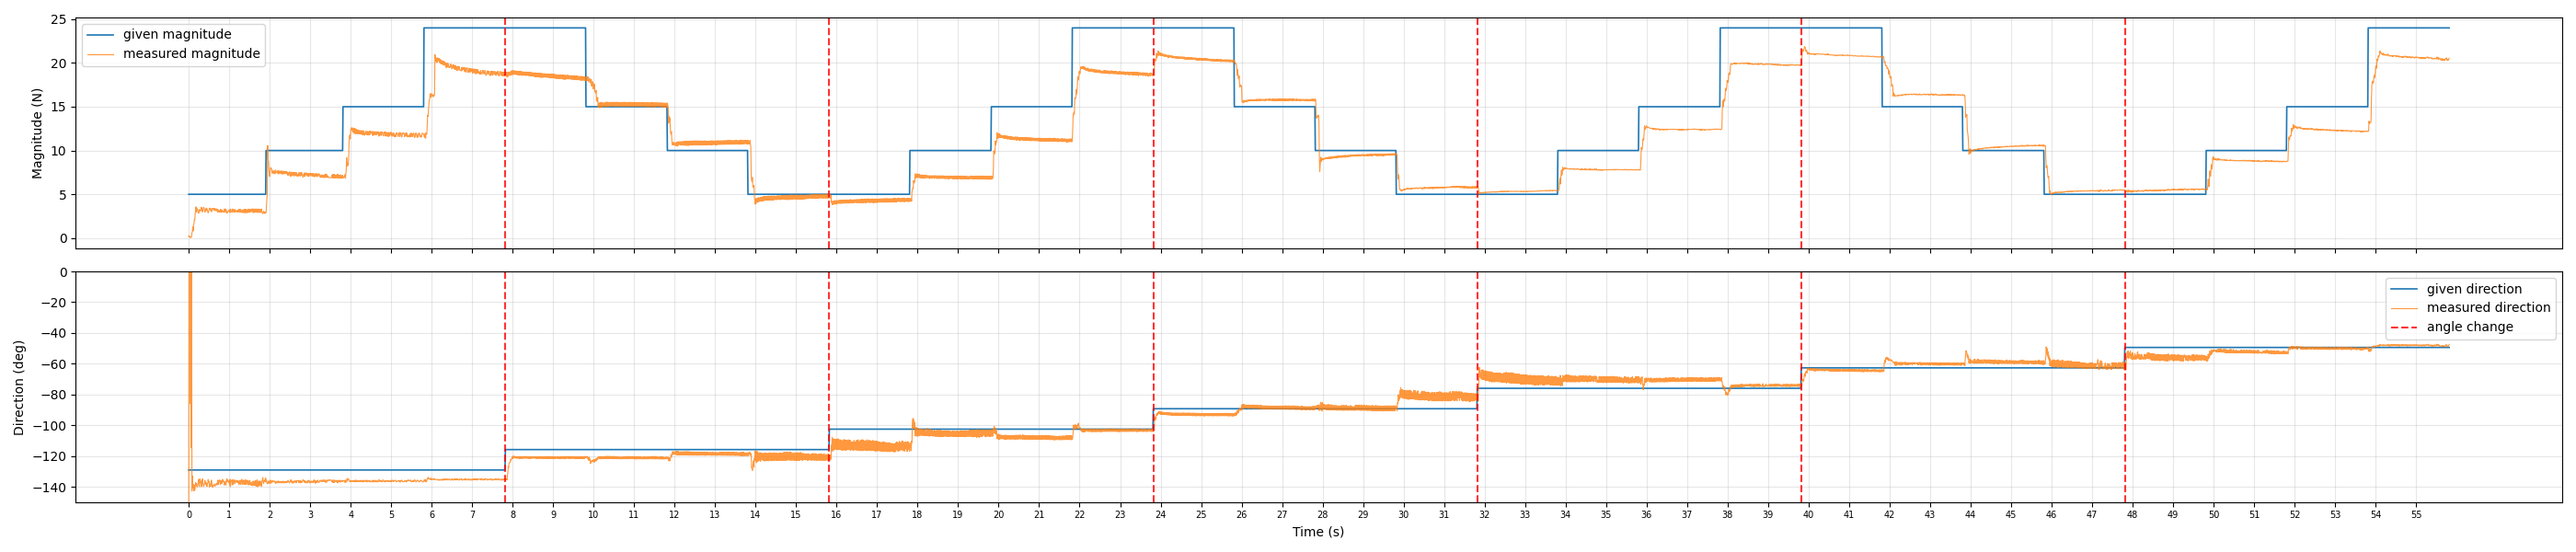

In [5]:
%matplotlib widget

fig, axes = plt.subplots(2, 1, figsize=(28, 6), sharex=True)

axes[0].plot(df["t_sec"], df["magnitude"],          label="given magnitude",    lw=1.2)
axes[0].plot(df["t_sec"], df["measured_magnitude"], label="measured magnitude", lw=0.8, alpha=0.8)
for t in angle_changes:
    axes[0].axvline(t, color="red", lw=1.5, ls="--", alpha=0.8)
axes[0].set_ylabel("Magnitude (N)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["t_sec"], df["direction"],          label="given direction",    lw=1.2)
axes[1].plot(df["t_sec"], df["measured_direction"], label="measured direction", lw=0.8, alpha=0.8)
for i, t in enumerate(angle_changes):
    axes[1].axvline(t, color="red", lw=1.5, ls="--", alpha=0.8,
                   label="angle change" if i == 0 else "")
axes[1].set_ylabel("Direction (deg)")
axes[1].set_ylim(-150, 0)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

t_max = int(df["t_sec"].max()) + 1
axes[1].set_xticks(range(0, t_max, 1))
axes[1].set_xticklabels(range(0, t_max, 1), fontsize=7)
axes[1].set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig(os.path.join(SESSION_DIR, "mag_dir_timeseries.png"), dpi=150)
plt.show()

## Cell 7 — Error Table per Step (Stable Window)

In [6]:
MAG_LIST = [5.0, 10.0, 15.0, 24.0]
MAG_TOL  = 1.0

# stable window = last STABLE_WIN seconds since actual command fired
stable = df[df["t_in_step"] >= HOLD_TIME - STABLE_WIN].copy()

# keep only rows whose commanded magnitude is one of the target levels
stable = stable[stable["magnitude"].apply(lambda m: any(abs(m - mg) < MAG_TOL for mg in MAG_LIST))]

print(f"Stable rows: {len(stable)}  (STABLE_WIN={STABLE_WIN}s, ~{round(STABLE_WIN*100)} rows/step)")
print(f"Steps in stable: {sorted(stable['step'].unique())}\n")

summary = stable.groupby("step").agg(
    angle     = ("direction",          "first"),
    given_mag = ("magnitude",          "first"),
    mean_meas = ("measured_magnitude", "mean"),
    mean_dir  = ("measured_direction", "mean"),
    n         = ("magnitude",          "count"),
).reset_index()
summary["mean_err"] = summary["mean_meas"] - summary["given_mag"]
summary["dir_err"]  = summary["mean_dir"]  - summary["angle"]

print("{:>5} | {:>12} | {:>10} | {:>14} | {:>10} | {:>12} | {:>10} | {:>7}".format(
      "Step", "Angle (deg)", "Given (N)", "Meas Mag (N)", "Mag Err", "Meas Dir (°)", "Dir Err", "Samples"))
print("-" * 100)
for _, row in summary.iterrows():
    if row["step"] > 0 and row["step"] % NUM_MAGS == 0:
        print()
    print("{:>5} | {:>12.1f} | {:>10.1f} | {:>14.3f} | {:>10.3f} | {:>12.1f} | {:>10.3f} | {:>7}".format(
          int(row["step"]), row["angle"], row["given_mag"], row["mean_meas"],
          row["mean_err"], row["mean_dir"], row["dir_err"], int(row["n"])))

Stable rows: 2782  (STABLE_WIN=1.0s, ~100 rows/step)
Steps in stable: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]

 Step |  Angle (deg) |  Given (N) |   Meas Mag (N) |    Mag Err | Meas Dir (°) |    Dir Err | Samples
----------------------------------------------------------------------------------------------------
    0 |       -129.1 |        5.0 |          3.088 |     -1.912 |       -137.2 |     -8.093 |      91
    1 |       -129.1 |       10.0 |          7.103 |     -2.897 |       -136.4 |     -7.296 |      90
    2 |       -129.1 |       15.0 |         11.807 |     -3.193 |       -136.3 |     -7.190 |      99
    3 |       -129.1 |       24.0 |         18.935 |     -5.065 |       -135.3 |     -6.152 |     101

    4 |       -115.9 |       24.0 |         18.382 |     -5.618 |       -121.1 |     -5.210 |      99
    5 |       -115.9 |       15.0 |         15.236 |      0.236 |       -121.2 |     -5.368 |     101
    6 |   

In [7]:
targets = pd.read_csv(os.path.join(SESSION_DIR, "sweep_targets.csv"), parse_dates=["timestamp"])
targets["t_cmd"] = (targets["timestamp"] - targets["timestamp"].iloc[0]).dt.total_seconds()
targets["expected_t"] = targets["step"] * HOLD_TIME
targets["drift_ms"] = (targets["t_cmd"] - targets["expected_t"]) * 1000
print(targets[["step", "t_cmd", "expected_t", "drift_ms"]].to_string(index=False))
print(f"\nMax drift: {targets['drift_ms'].abs().max():.1f} ms  (step {targets['drift_ms'].abs().idxmax()})")
print(f"Mean drift: {targets['drift_ms'].mean():.1f} ms")

 step     t_cmd  expected_t  drift_ms
    0  0.000000         0.0     0.000
    1  1.907520         2.0   -92.480
    2  3.808128         4.0  -191.872
    3  5.810117         6.0  -189.883
    4  7.809176         8.0  -190.824
    5  9.809063        10.0  -190.937
    6 11.810517        12.0  -189.483
    7 13.808769        14.0  -191.231
    8 15.809604        16.0  -190.396
    9 17.808516        18.0  -191.484
   10 19.809041        20.0  -190.959
   11 21.809372        22.0  -190.628
   12 23.816343        24.0  -183.657
   13 25.810429        26.0  -189.571
   14 27.809051        28.0  -190.949
   15 29.808905        30.0  -191.095
   16 31.808577        32.0  -191.423
   17 33.808800        34.0  -191.200
   18 35.810533        36.0  -189.467
   19 37.811523        38.0  -188.477
   20 39.811619        40.0  -188.381
   21 41.811464        42.0  -188.536
   22 43.808879        44.0  -191.121
   23 45.808424        46.0  -191.576
   24 47.808854        48.0  -191.146
   25 49.808

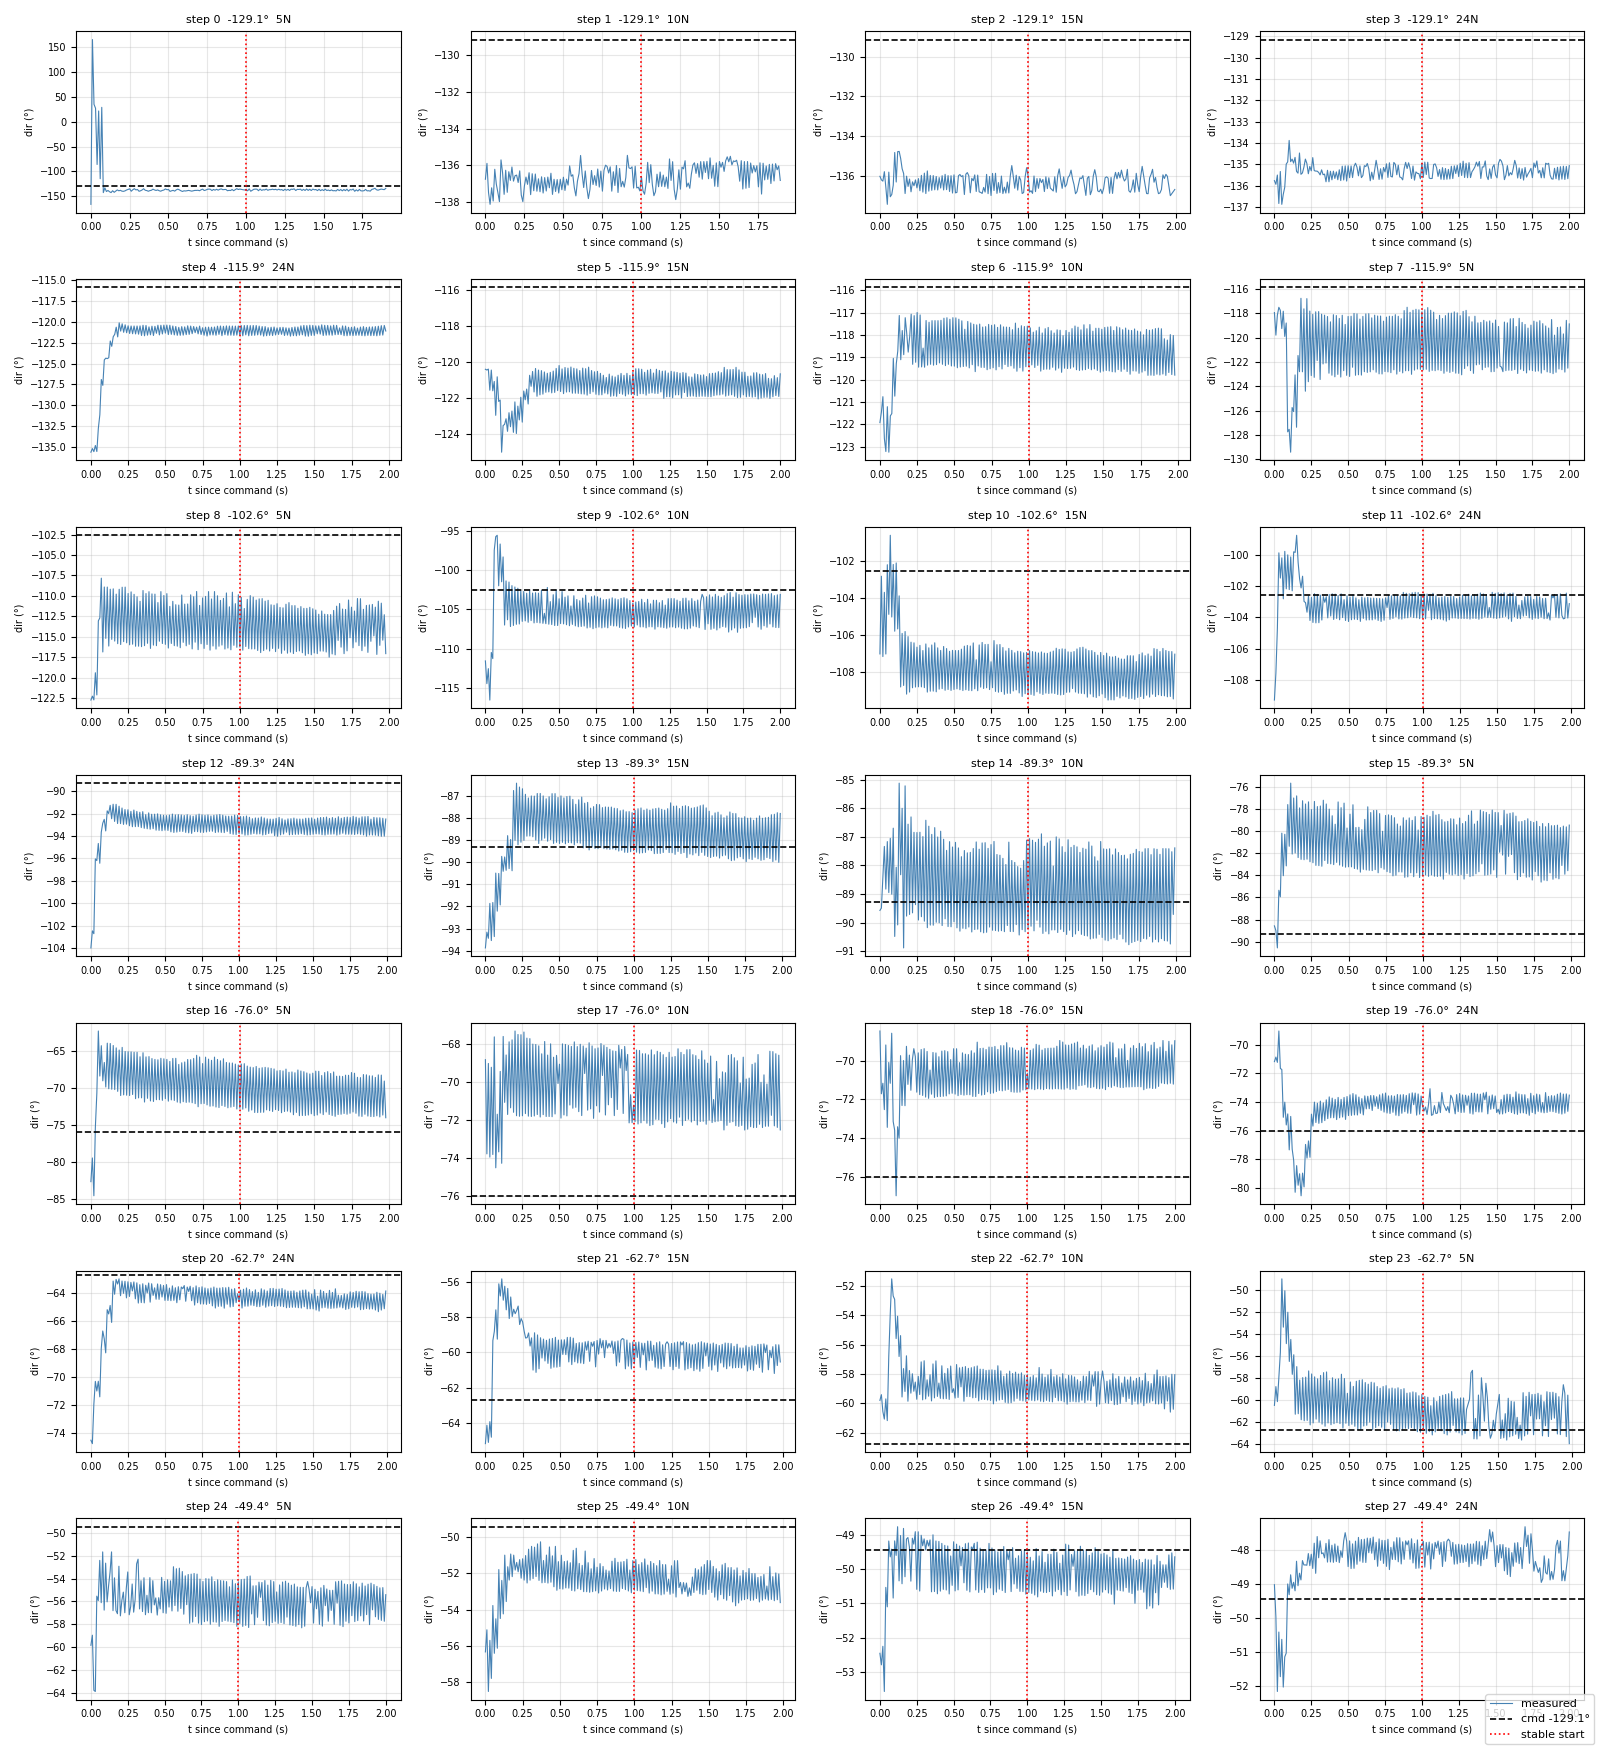

In [8]:
%matplotlib widget

step_ids = sorted(df["step"].unique())
ncols = 4
nrows = (len(step_ids) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 2.5), sharey=False)
axes = axes.flatten()

for ax, step_id in zip(axes, step_ids):
    chunk = df[df["step"] == step_id].copy()
    cmd_dir = chunk["direction"].iloc[0]
    mag = chunk["magnitude"].iloc[0]

    ax.plot(chunk["t_in_step"], chunk["measured_direction"], lw=0.8, color="steelblue", label="measured")
    ax.axhline(cmd_dir, color="black", lw=1.2, ls="--", label=f"cmd {cmd_dir:.1f}°")
    ax.axvline(HOLD_TIME - STABLE_WIN, color="red", lw=1.2, ls=":", label="stable start")

    ax.set_title(f"step {step_id}  {cmd_dir:.1f}°  {mag:.0f}N", fontsize=8)
    ax.set_xlabel("t since command (s)", fontsize=7)
    ax.set_ylabel("dir (°)", fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

for ax in axes[len(step_ids):]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(SESSION_DIR, "settling_diagnostic.png"), dpi=150)
plt.show()

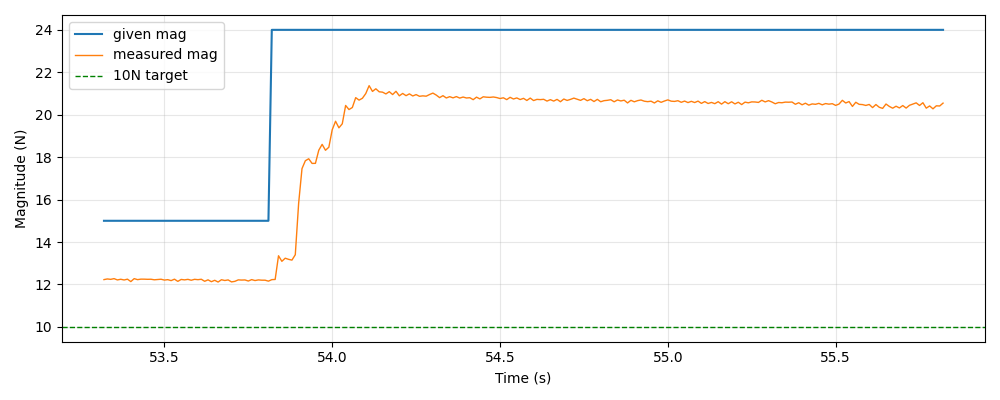

In [9]:
mask = (df["t_sec"] >= df.loc[df["step"] == 27, "t_sec"].min() - 0.5) & \
       (df["t_sec"] <= df.loc[df["step"] == 27, "t_sec"].max() + 0.5)
chunk = df[mask]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(chunk["t_sec"], chunk["magnitude"],          label="given mag",    lw=1.5)
ax.plot(chunk["t_sec"], chunk["measured_magnitude"], label="measured mag", lw=1.0)
ax.axhline(10, color="green", ls="--", lw=1, label="10N target")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Magnitude (N)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SESSION_DIR, "step_zoom.png"), dpi=150)
plt.show()

## Cell 8 — Error Bar Chart per Step

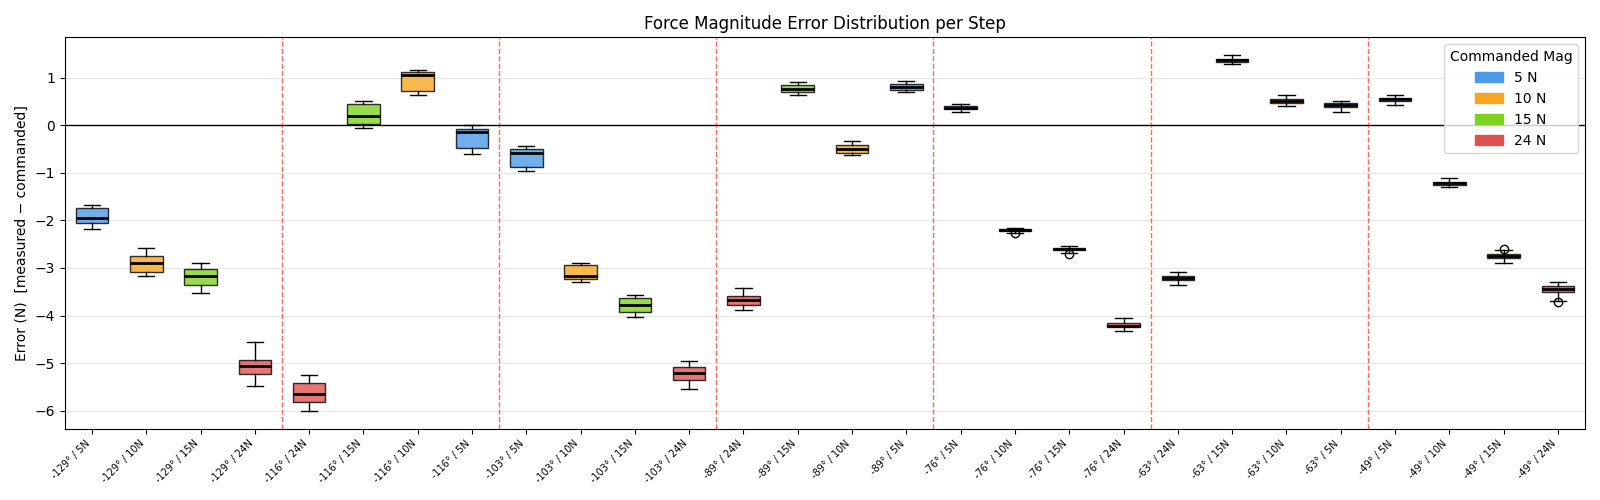

In [10]:
mag_colors = {5.0: "#4c9be8", 10.0: "#f5a623", 15.0: "#7ed321", 24.0: "#e05252"}

stable["err_magnitude"] = stable["measured_magnitude"] - stable["magnitude"]

box_data      = []
box_labels    = []
box_colors    = []
sep_positions = []

for i, row in summary.iterrows():
    errs = stable.loc[stable["step"] == row["step"], "err_magnitude"].values
    box_data.append(errs)
    box_labels.append("{:.0f}° / {:.0f}N".format(row["angle"], row["given_mag"]))
    box_colors.append(mag_colors.get(round(row["given_mag"]), "grey"))
    if row["step"] > 0 and row["step"] % NUM_MAGS == 0:
        sep_positions.append(i + 0.5)

fig, ax = plt.subplots(figsize=(16, 5))
bp = ax.boxplot(box_data, patch_artist=True, widths=0.6,
                medianprops=dict(color="black", lw=2))
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.axhline(0, color="black", lw=1.0)
for x in sep_positions:
    ax.axvline(x, color="red", lw=1.0, ls="--", alpha=0.6)

ax.set_xticks(range(1, len(box_labels) + 1))
ax.set_xticklabels(box_labels, fontsize=7, rotation=45, ha="right")
ax.set_ylabel("Error (N)  [measured − commanded]")
ax.set_title("Force Magnitude Error Distribution per Step")
ax.grid(True, axis="y", alpha=0.3)

from matplotlib.patches import Patch
legend = [Patch(color=c, label="{:.0f} N".format(m)) for m, c in mag_colors.items()]
ax.legend(handles=legend, title="Commanded Mag", loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(SESSION_DIR, "error_boxplot.png"), dpi=150)
plt.show()